### Import Libralies

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Import Data

In [ ]:
df = pd.read_csv('train_subset.csv')


In [72]:
stat_original = df.describe()
print(stat_original.to_string(formatters={col: '{:.2f}'.format for col in stat_original.columns}))

            id      age   gender   height   weight    ap_hi    ap_lo cholesterol     gluc
count 56000.00 56000.00 56000.00 56000.00 56000.00 56000.00 56000.00    56000.00 56000.00
mean  49997.02 19466.63     1.35   164.34    74.22   129.04    96.80        1.37     1.23
std   28874.26  2461.79     0.48     8.23    14.39   161.55   193.57        0.68     0.57
min       0.00 10859.00     1.00    57.00    11.00  -150.00   -70.00        1.00     1.00
25%   24993.75 17669.50     1.00   159.00    65.00   120.00    80.00        1.00     1.00
50%   50001.50 19698.00     1.00   165.00    72.00   120.00    80.00        1.00     1.00
75%   74949.50 21321.00     2.00   170.00    82.00   140.00    90.00        2.00     1.00
max   99999.00 23692.00     2.00   250.00   200.00 16020.00 11000.00        3.00     3.00


### Preprocessing

Handle missing values

In [56]:
# see if there is any missing value in the dataset
print(df.isnull().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


### Remove outliers and anomalies value from columns 'height', 'weight', 'ap_hi', 'ap_lo'

In [57]:
def remove_outliers(column, threshold, dataset):
    rows_before = len(dataset)
    Q1 = dataset[column].quantile(0.25)
    Q3 = dataset[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    print(f"Column: {column}")
    print(f"New Lower bound: {lower_bound}, New Upper bound: {upper_bound} ({column} column)")
    dataset = dataset[(dataset[column] >= lower_bound) & (dataset[column] <= upper_bound)]
    rows_after = len(dataset)
    print(f"{rows_before - rows_after} rows removed from the dataset due to outliers in {column}.")
    return dataset

In [58]:
print(f"Number of rows before remove the outliers in the dataset: {len(df)}")
df = remove_outliers('height', 2.5, df)
df = remove_outliers('weight', 1.5, df)
df = remove_outliers('ap_hi', 1.5, df)
df = remove_outliers('ap_lo', 2.5, df)
print(f"Number of rows after remove the outliers in the dataset: {len(df)}")

# check which rows have ap_hi < ap_lo
anomalies = df[df['ap_hi'] < df['ap_lo']]
print(anomalies)

# remove anomaly rows in the dataset (ap_hi < ap_lo)
df = df[df['ap_hi'] >= df['ap_lo']]
print(f"Number of rows after remove the anomaly rows in the dataset: {len(df)}")

Number of rows before remove the outliers in the dataset: 56000
Column: height
New Lower bound: 131.5, New Upper bound: 197.5 (height column)
103 rows removed from the dataset due to outliers in height.
Column: weight
New Lower bound: 39.5, New Upper bound: 107.5 (weight column)
1471 rows removed from the dataset due to outliers in weight.
Column: ap_hi
New Lower bound: 90.0, New Upper bound: 170.0 (ap_hi column)
1017 rows removed from the dataset due to outliers in ap_hi.
Column: ap_lo
New Lower bound: 55.0, New Upper bound: 115.0 (ap_lo column)
792 rows removed from the dataset due to outliers in ap_lo.
Number of rows after remove the outliers in the dataset: 52617
          id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
26713  32702  20467       2     178    84.0     95    100            1     1   
33905  66423  15215       2     178    92.0     90    100            1     1   

      smoke alco active cardio  
26713    No  Yes     No    Yes  
33905   Yes   No 

In [59]:
stat_processed = df.describe()
print(stat_processed.to_string(formatters={col: '{:.2f}'.format for col in stat_processed.columns}))

            id      age   gender   height   weight    ap_hi    ap_lo cholesterol     gluc
count 52615.00 52615.00 52615.00 52615.00 52615.00 52615.00 52615.00    52615.00 52615.00
mean  49973.24 19451.24     1.35   164.35    72.95   125.65    80.91        1.35     1.22
std   28896.03  2464.21     0.48     7.71    12.34    15.04     8.82        0.67     0.56
min       0.00 10859.00     1.00   132.00    40.00    90.00    55.00        1.00     1.00
25%   24896.50 17649.00     1.00   159.00    65.00   120.00    80.00        1.00     1.00
50%   50001.00 19692.00     1.00   165.00    71.00   120.00    80.00        1.00     1.00
75%   74924.50 21310.00     2.00   170.00    80.00   140.00    90.00        1.00     1.00
max   99999.00 23692.00     2.00   197.00   107.00   170.00   115.00        3.00     3.00


### Convert "Age" column from days to years

In [60]:
df['age_years'] = (df['age'] / 365).astype(float)
df.drop(columns='age', inplace=True)

### Drop "id" column

In [61]:
df = df.drop(columns=['id'])

In [62]:
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,162,83.0,120,80,1,1,No,No,No,Yes,52.041096
1,1,158,64.0,120,80,1,1,No,No,Yes,No,47.449315
2,1,165,95.0,160,100,2,1,No,No,Yes,Yes,52.101370
3,1,164,83.0,150,100,1,1,No,No,Yes,Yes,55.857534
4,1,156,52.0,100,67,1,1,No,No,No,No,49.961644
...,...,...,...,...,...,...,...,...,...,...,...,...
55995,1,165,53.0,120,75,1,1,No,No,Yes,Yes,57.767123
55996,2,169,68.0,120,80,1,3,No,Yes,Yes,No,60.216438
55997,2,170,74.0,120,80,1,1,No,No,No,Yes,54.602740
55998,1,169,91.0,130,90,1,1,No,No,No,Yes,57.293151


### Binarization for column "gender", "smoke", "alco", "active", "cardio"

In [63]:
df['gender'] = df['gender'].map({1: 0, 2: 1}) # 0: women, 1:men
df['smoke'] = df['smoke'].map({"No": 0, "Yes": 1})
df['alco'] = df['alco'].map({"No": 0, "Yes": 1})
df['active'] = df['active'].map({"No": 0, "Yes": 1})
df['cardio'] = df['cardio'].map({"No": 0, "Yes": 1})

### Feature engineering

In [64]:
# add bmi column to the dataset
df['BMI'] = df['weight'] / ((df['height']/100) ** 2)

# add BMI category column to the dataset
# 1: underweight, 2: normal weight, 3: overweight, 4: obese
# underweight: BMI < 18.5
# normal weight: 18.5 <= BMI < 24.9
# overweight: 24.9 <= BMI < 29.9
# obese: BMI >= 29.9

df['BMI_category'] = pd.cut(df['BMI'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=[1, 2, 3, 4])
df['BMI_category'] = df['BMI_category'].astype(int)

In [65]:
# add pulse pressure column to the dataset
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

In [66]:
# add cardio column as the last colun to the dataset
copy_cardio = df["cardio"]
df.drop(columns='cardio', inplace=True)
df["cardio"] = copy_cardio
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,BMI,BMI_category,pulse_pressure,cardio
0,1,162,83.0,120,80,1,1,0,0,0,52.041096,31.626276,4,40,1
1,0,158,64.0,120,80,1,1,0,0,1,47.449315,25.636917,3,40,0
2,0,165,95.0,160,100,2,1,0,0,1,52.101370,34.894399,4,60,1
3,0,164,83.0,150,100,1,1,0,0,1,55.857534,30.859607,4,50,1
4,0,156,52.0,100,67,1,1,0,0,0,49.961644,21.367521,2,33,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55995,0,165,53.0,120,75,1,1,0,0,1,57.767123,19.467401,2,45,1
55996,1,169,68.0,120,80,1,3,0,1,1,60.216438,23.808690,2,40,0
55997,1,170,74.0,120,80,1,1,0,0,0,54.602740,25.605536,3,40,1
55998,0,169,91.0,130,90,1,1,0,0,0,57.293151,31.861629,4,40,1


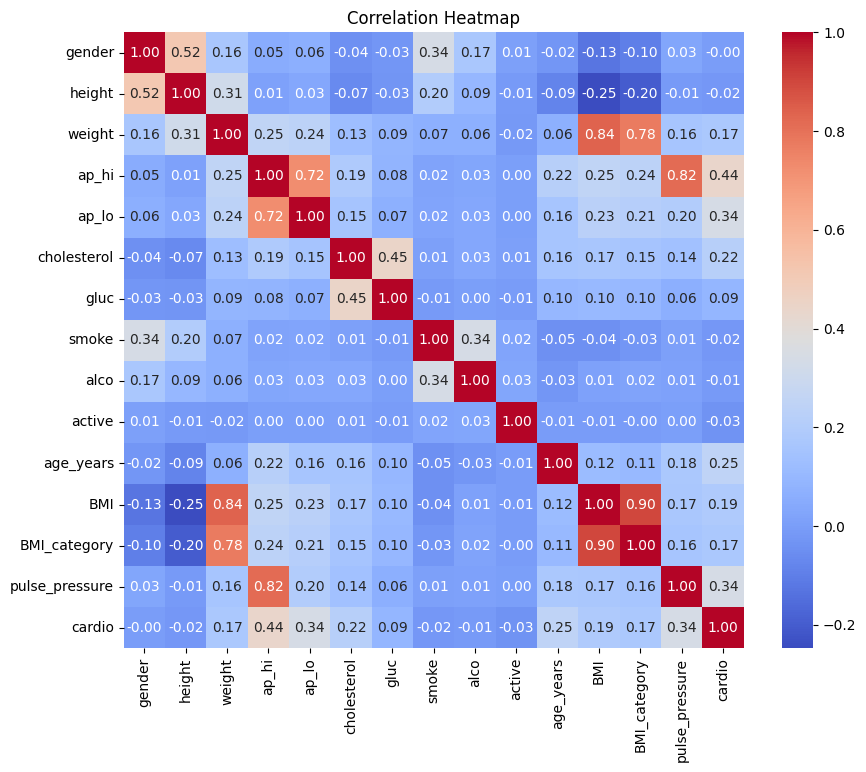

In [67]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr('pearson')
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Feature Selection

In [68]:
# top 10 features with the highest correlation with the target variable
top_10_features = correlation_matrix['cardio'].abs().nlargest(11).index[0:]
print("Top 10 features with the highest correlation with the target variable:")
print(top_10_features)

Top 10 features with the highest correlation with the target variable:
Index(['cardio', 'ap_hi', 'ap_lo', 'pulse_pressure', 'age_years',
       'cholesterol', 'BMI', 'BMI_category', 'weight', 'gluc', 'active'],
      dtype='object')


In [69]:
df.drop(columns=[col for col in df.columns if col not in top_10_features], inplace=True)
df

,weight,ap_hi,ap_lo,cholesterol,gluc,active,age_years,BMI,BMI_category,pulse_pressure,cardio
0,83.0,120,80,1,1,0,52.041096,31.626276,4,40,1
1,64.0,120,80,1,1,1,47.449315,25.636917,3,40,0
2,95.0,160,100,2,1,1,52.101370,34.894399,4,60,1
3,83.0,150,100,1,1,1,55.857534,30.859607,4,50,1
4,52.0,100,67,1,1,0,49.961644,21.367521,2,33,0
...,...,...,...,...,...,...,...,...,...,...,...
55995,53.0,120,75,1,1,1,57.767123,19.467401,2,45,1
55996,68.0,120,80,1,3,1,60.216438,23.808690,2,40,0
55997,74.0,120,80,1,1,0,54.602740,25.605536,3,40,1
55998,91.0,130,90,1,1,0,57.293151,31.861629,4,40,1


Save to .csv for using in KNIME or Classifier

In [70]:
# save to csv file (not yet normalized)
df.to_csv('processed_dataset.csv', index=False)